With Vanilla GD:
the loss normally drops at each step in gradient descent. On the other hand, the accuracy climbs—but not necessarily at each and every step.


Mini-batch Gradient Descent
It segments the training set into smaller batches, and then takes a step of gradient descent for each batch.

- converge faster, faster at approaching minimum loss -> speed up model training
- No need to keep terabytes of data in memory for large data training
- Divide data into bacthes and we can perform parallel training with GPU/TPU
- Due to it's random fluctuation might not get stuck forever in local minima

In [15]:
#imports
import numpy as np
import struct
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [1]:
#batch dataset
def prepare_batches(X_train,Y_train,batch_size):
    x_batches=[]
    y_batches=[]
    n_examples = X_train.shape[0]
    
    for batch in range(0,n_examples,batch_size):
        batch_end = batch+batch_size
        x_batches.append(X_train[batch:batch_end])
        y_batches.append(Y_train[batch:batch_end])

    return x_batches,y_batches

In [3]:
#load MNIST dataset
def load_images(filename):
    with open(filename,'rb') as f:
        _ignored,n_images,columns,rows = struct.unpack('>IIII',f.read(16))
        all_pixels = np.frombuffer(f.read(),dtype=np.uint8)
        return all_pixels.reshape(n_images,columns*rows)

# 60000 images, each 785 elements (1 bias + 28 * 28 pixels)
X_train = load_images("Datasets/archive/train-images-idx3-ubyte/train-images-idx3-ubyte")

# 10000 images, each 785 elements, with the same structure as X_train
X_test = load_images("Datasets/archive/t10k-images-idx3-ubyte/t10k-images-idx3-ubyte")

def load_labels(filename):
    with open(filename,'rb') as f:
        f.read(8)
        all_labels = f.read()
        return np.frombuffer(all_labels,dtype=np.uint8).reshape(-1,1)

def one_hot_encode(Y):
    n_labels = Y.shape[0]
    n_classes = 10
    encoded_Y = np.zeros((n_labels,n_classes))

    for i in range(n_labels):
        label = Y[i]
        encoded_Y[i][label] = 1
    return encoded_Y

Y_train_unencoded = load_labels("Datasets/archive/train-labels-idx1-ubyte/train-labels-idx1-ubyte")

Y_train = one_hot_encode(Y_train_unencoded)

Y_test = load_labels("Datasets/archive/t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte")


In [5]:
#Neural Network development

#sigmoid
def sigmoid(z):
    return 1/(1+np.exp(-z))

#sigmoid gradient
def sigmoid_gradient(sigmoid):
    return np.multiply(sigmoid,(1-sigmoid))

#softmax
def softmax(logits):
    exponentials = np.exp(logits)
    return exponentials/ np.sum(exponentials,axis=1).reshape(-1,1)

#prepend bias only in training dataset X
def prepend_bias(X):
    return np.insert(X,0,1,axis=1)

#forward prop
def forward(X,w1,w2):
    h = sigmoid(np.matmul(prepend_bias(X),w1))
    y_hat = softmax(np.matmul(prepend_bias(h),w2))
    return (y_hat,h)

#log loss
def loss(Y,y_hat):
    return -np.sum(Y*np.log(y_hat))/Y.shape[0]

#back prop
def back(X,Y,y_hat,w2,h):
    w2_gradient = np.matmul(prepend_bias(h).T,(y_hat-Y)) / X.shape[0]
    w1_gradient = np.matmul(prepend_bias(X).T, np.matmul(y_hat-Y,w2[1:].T)
                            * sigmoid_gradient(h))/X.shape[0]
    return (w1_gradient,w2_gradient)

#predict or classify
def classify(X,w1,w2):
    y_hat,_ = forward(X,w1,w2)
    labels = np.argmax(y_hat,axis=1)
    return labels.reshape(-1,1)

#Initialize weights
def initialize_weights(n_input_variables,n_hidden_nodes,n_classes):
    w1_rows = n_input_variables + 1 #bias
    w1 = np.random.randn(w1_rows,n_hidden_nodes) * np.sqrt(1/w1_rows)

    w2_rows = n_hidden_nodes + 1
    w2 = np.random.randn(w2_rows,n_classes) * np.sqrt(1/w2_rows)

    return (w1,w2)

In [10]:
#print details of each iteration
def report(epoch,batch,X_train,Y_train,X_test,Y_test,w1,w2):
    y_hat,_ = forward(X_train,w1,w2)
    training_loss = loss(Y_train,y_hat)
    classification = classify(X_test,w1,w2)
    accuracy = np.average(classification == Y_test) * 100.0
    print("%5d-%d > Loss: %.8f, Accuracy:%.2f%%" % (epoch,batch,training_loss,accuracy))

#triaing the NN
def train(X_train,Y_train,X_test,Y_test,n_hidden_nodes,epochs,batch_size,lr):
    n_input_variables = X_train.shape[1]
    n_classes = Y_train.shape[1]

    #initialize random weights
    w1,w2 = initialize_weights(n_input_variables,n_hidden_nodes,n_classes)
    x_batches,y_batches = prepare_batches(X_train,Y_train,batch_size)
    for epoch in range(epochs):
        for batch in range(len(x_batches)):
            y_hat,h = forward(x_batches[batch],w1,w2)
            w1_gradient,w2_gradient = back(x_batches[batch],y_batches[batch],
                                           y_hat,w2,h)
            w1-=(w1_gradient*lr)
            w2-=(w2_gradient*lr)
            report(epoch,batch,X_train,Y_train,X_test,Y_test,w1,w2)
    return (w1,w2)

In [11]:
w1,w2 = train(X_train,Y_train,X_test,Y_test,200,2,20000,0.01)

    0-0 > Loss: 2.41764553, Accuracy:12.04%
    0-1 > Loss: 2.37229389, Accuracy:13.62%
    0-2 > Loss: 2.33044518, Accuracy:15.33%
    1-0 > Loss: 2.29193792, Accuracy:17.05%
    1-1 > Loss: 2.25649657, Accuracy:18.75%
    1-2 > Loss: 2.22274938, Accuracy:20.68%


Large batch size led to really low accuracy

How small batch size should be?

In [13]:
w1,w2 = train(X_train,Y_train,X_test,Y_test,200,2,256,0.01)

    0-0 > Loss: 2.58156001, Accuracy:9.36%
    0-1 > Loss: 2.47493390, Accuracy:9.46%
    0-2 > Loss: 2.40046695, Accuracy:10.32%
    0-3 > Loss: 2.34230073, Accuracy:11.27%
    0-4 > Loss: 2.29273702, Accuracy:12.49%
    0-5 > Loss: 2.24896520, Accuracy:13.95%
    0-6 > Loss: 2.20558917, Accuracy:15.63%
    0-7 > Loss: 2.17232723, Accuracy:17.64%
    0-8 > Loss: 2.13494076, Accuracy:21.03%
    0-9 > Loss: 2.10695644, Accuracy:23.40%
    0-10 > Loss: 2.07641857, Accuracy:26.86%
    0-11 > Loss: 2.05029217, Accuracy:29.70%
    0-12 > Loss: 2.02676868, Accuracy:31.63%
    0-13 > Loss: 2.00390384, Accuracy:34.28%
    0-14 > Loss: 1.98144086, Accuracy:36.93%
    0-15 > Loss: 1.96076609, Accuracy:39.33%
    0-16 > Loss: 1.93790511, Accuracy:41.23%
    0-17 > Loss: 1.91799318, Accuracy:43.20%
    0-18 > Loss: 1.89894473, Accuracy:44.92%
    0-19 > Loss: 1.87974632, Accuracy:46.33%
    0-20 > Loss: 1.86313335, Accuracy:47.51%
    0-21 > Loss: 1.84218035, Accuracy:48.75%
    0-22 > Loss: 1.824

![My Image](Images/Vanilla%20GD%20vs%20mini-batch%20GD.png)

Let’s understand thing clearly that, while mini-batch GD easily wins the speed race, it would not necessarily win the entire process. If we keep the experiment running for hours, then batch GD might eventually catch up. In the short term, however, mini-batch GD gives us quicker feedback, and which we care about while we tune the network. With mini-batch GD, it takes a few minutes to see how well our network is doing. With batch GD, it takes multiple times as much.

Mini-batch GD feels counter-intuitive. Why do smaller batches result in faster training? The answer is that they do not: mini-batch GD is generally slower than batch GD at processing the whole training set because it calculates the gradient for each batch rather than once for all the examples.

mini-batch GD is slower at processing the training set, but it moves quickly toward the target, giving us that fast feedback we need.



stochastic gradient descent, where “stochastic” is the statistical term for randomly distributed. The idea of stochastic gradient descent is that we select one random example per iteration and take a step of GD based on that one example.

Let's compare how model perform with different batch size:

1. 1(stochastic GD)
2. 32(mini-batch GD with smaller batches)
3. 128(mini-batch GD with larger batches)
4. 60000(batch GD - one batch for entire training set)

In [37]:
# Utility functions to compare different configurations of the network.

#below train function is different from original function in few was:
# * it goes on until a specified time has passed, rather than after a specified
#   number of epochs;
# * it does its job quietly instead of reporting the loss and accuracy at each
#   step;
# * it stores the loss and the time passed after each step, so that it can
#   return that history to the caller;
# * it also returns the number of training epochs and the total number of
#   gradient descent steps.


def train(X_train,Y_train,X_test,Y_test,n_hidden_nodes,
          batch_size,lr,time_in_seconds):

    
      n_input_variables = X_train.shape[1]
      n_classes = Y_train.shape[1]

      w1,w2 = initialize_weights(n_input_variables,n_hidden_nodes,n_classes)
      #print(str(X_train.shape) + "," + str(Y_train.shape) + "," + str(batch_size))
      x_batches,y_batches = prepare_batches(X_train,Y_train,batch_size)

      start_time = time.time()
      times = []
      losses = []
      epochs = 0
      steps = 0
      while True:
            
        
            batch = 0
            while (batch < len(x_batches)):
                  training_classifications, _ = forward(X_train,w1,w2)
                  training_loss = loss(Y_train,training_classifications)
                  times.append(np.floor(time.time()-start_time))
                  losses.append(training_loss)

                  time_passed = time.time() - start_time
                  if time_passed > time_in_seconds:
                        return (times,losses,epochs,steps)
            
                  y_hat,h = forward(x_batches[batch],w1,w2)
                  w1_gradient,w2_gradient = back(x_batches[batch],
                                           y_batches[batch],y_hat,w2,h)
                  w1 = w1-(w1_gradient*lr)
                  w2 = w2-(w2_gradient*lr)

                  batch+=1
                  steps+=1
      
            epochs +=1

def plot_loss(X_train,Y_train,X_test,Y_test,n_hidden_nodes,batch_size,lr,
              time_in_seconds,label,color,linestyle):

            print("Training: ",label)
            times,losses,epochs,steps = train(X_train,Y_train,X_test,Y_test,
                                              n_hidden_nodes,batch_size,
                                              lr,time_in_seconds)
            
            print("Loss: %.8f (%d epochs completed, %d total steps)" %
                  (losses[-1],epochs,steps))
            plt.plot(times,losses,label=label,color=color,linestyle=linestyle)

def show_plot():
      sns.set()

      plt.xticks(fontsize=10)
      plt.yticks(fontsize=10)
      plt.xlabel("Seconds",fontsize=15)
      plt.ylabel("Loss",fontsize=15)
      #Add a legend and show the chart
      plt.legend(fontsize=10)
      plt.show()


In [38]:
TIME=20 #running time of each batch size, in seconds
HIDDEN_NODES = 200
lr = 0.01

np.random.seed(42)

Training:  Stochastic GD


/var/folders/33/d33y821d0gx3bx3vln89pxfc0000gn/T/ipykernel_49007/4119475716.py:5: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-z))


Loss: 2.24761689 (0 epochs completed, 48 total steps)
Training:  Batch Size 32
Loss: 1.62101703 (0 epochs completed, 54 total steps)
Training:  Batch Size 128
Loss: 1.45690634 (0 epochs completed, 53 total steps)
Training:  Batch GD
Loss: 1.93408915 (17 epochs completed, 17 total steps)


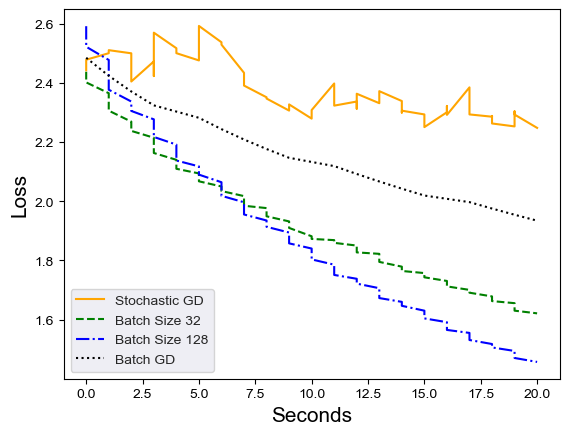

In [39]:
plot_loss(X_train,Y_train,X_test,Y_test,HIDDEN_NODES,1,lr,
              TIME,label="Stochastic GD",color="orange",linestyle='-')
plot_loss(X_train,Y_train,X_test,Y_test,HIDDEN_NODES,32,lr,
              TIME,label="Batch Size 32",color="green",linestyle='--')
plot_loss(X_train,Y_train,X_test,Y_test,HIDDEN_NODES,128,lr,
              TIME,label="Batch Size 128",color="blue",linestyle='-.')
plot_loss(X_train,Y_train,X_test,Y_test,HIDDEN_NODES,X_train.shape[0],lr,
              TIME,label="Batch GD",color="black",linestyle=':')

show_plot()

We can see clearly that the stochastic GD might work well for some other problems, but not our particular problem and network configuration.

In our case, it results in a loss that hops around irregularly and does not seem to drop much over time.

As the batch size increases, the loss gets smoother. That happens because the more examples we have, the more likely their average loss approximates the average loss of the entire training set. As a result, each step of gradient descent is more likely to end up closer to the goal, rather than further away from it.

However, it is not necessarily better. Batch GD is smooth, but it does not give us the fastest feedback nor the best final loss. A batch size of 32 gives us faster feedback in the first few iterations and a lower loss at the end of the experiment, even though batch GD seems likely to catch up in the long term. A batch size of 128 does even better, with great short-term feedback and a very low final loss. We do not know what happens after 10 or 100 hours of training, but a batch size of 128 looks like a safe bet so far.

And that’s what happens when we use different batch sizes on our specific problem.